# 05 · Test-Time Adaptation: CIFAR-10-C & Online Collapse

Real image TTA. Per-corruption CIFAR-10-C is *helpful-dominated* (Tent helps; KGA matches it safely).
A decisive CIFAR-10-C+Tent run shows KGA beating both baselines; the **online continual-Tent** stream
is where Tent *collapses* and KGA holds — the cross-regime robustness story.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); TV=os.path.join(REPO,'experiments','kbound','theory_validation')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


In [2]:
c=jload('cifar10c_suite_results.json'); c=c.get('summary',c)
print('### CIFAR-10-C suite (65 cells)'); print(' avg_acc:',c.get('avg_accuracy')); print(' false_adapt:',c.get('false_adapt_rate'))
d=jload('decisive_tta_results.json')
try:
    mt=d['benchmarks']['cifar10c']['methods']['tent']['metrics']; print('\n### CIFAR-10-C + Tent (decisive)'); print(' mean_acc:',mt['mean_acc']); print(' regret:',mt['regret_vs_oracle'])
except Exception as e: print('decisive_tta:',e)
o=jload('cifar_tent_online_results.json')
print('\n### Online continual-Tent (harsh)'); print(' mean_stream_acc:',o.get('mean_stream_accuracy')); print(' kga_decisions:',o.get('kga_decision_counts'))

### CIFAR-10-C suite (65 cells)
 avg_acc: {'frozen': 0.4121153843804048, 'tent': 0.6258846148275412, 'eata': 0.6257499996859294, 'sar': 0.6268461520282121, 'kga': 0.6257499998578658, 'oracle': 0.6289038488498101}
 false_adapt: {'frozen': 0.0, 'tent': 0.015384615384615385, 'eata': 0.015384615384615385, 'sar': 0.015384615384615385, 'kga': 0.015384615384615385}

### CIFAR-10-C + Tent (decisive)
 mean_acc: {'always_adapt': 0.7856539342966344, 'always_freeze': 0.6710555569303257, 'K_Bound': 0.792650462852584, 'oracle': 0.7942476845173924}
 regret: {'always_adapt': 0.008593750220757944, 'always_freeze': 0.12319212758706675, 'K_Bound': 0.0015972216648084145}

### Online continual-Tent (harsh)
 mean_stream_acc: {'freeze': [0.4398148148148148, 0.008880792391911349], 'adapt': [0.3393132716049383, 0.025083466087578426], 'kga': [0.42573302469135804, 0.009138918661168735], 'oracle': [0.6304976851851852, 0.006992503456941294]}
 kga_decisions: {'ADAPT': 40, 'FREEZE': 12, 'ABSTAIN': 2}


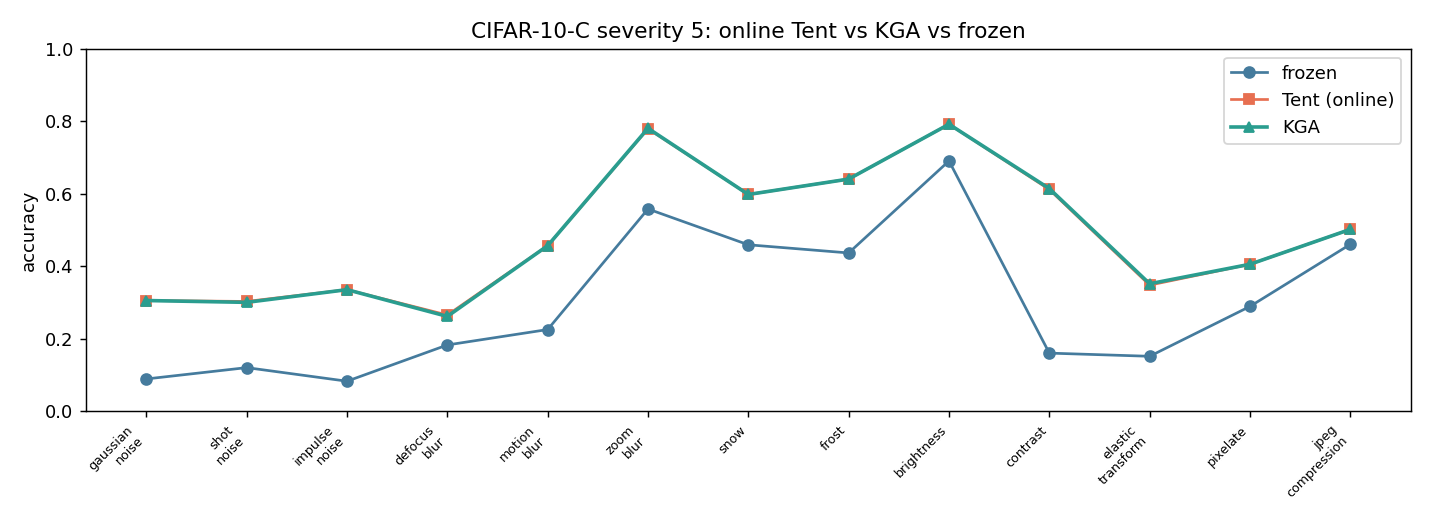

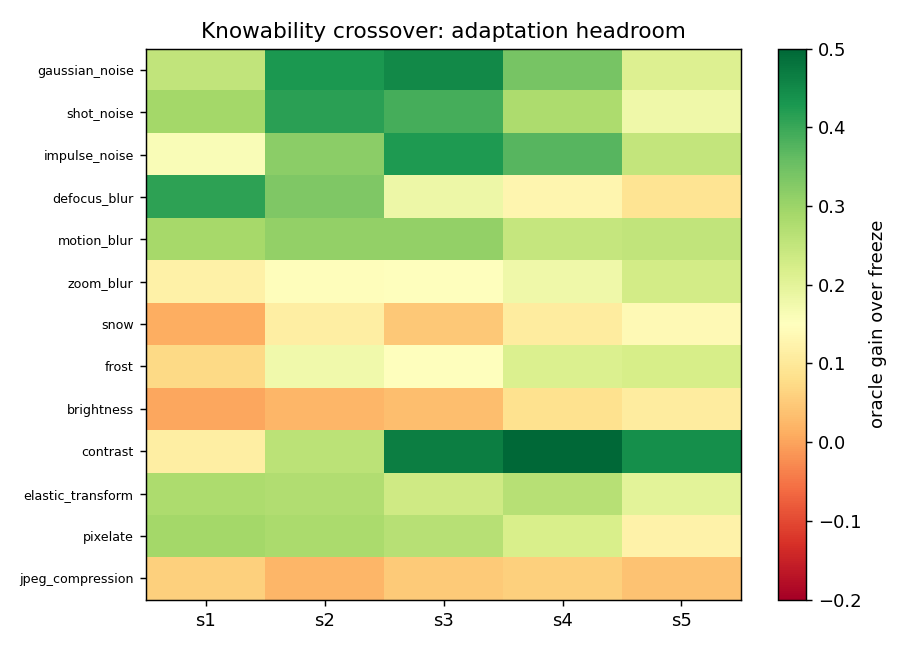

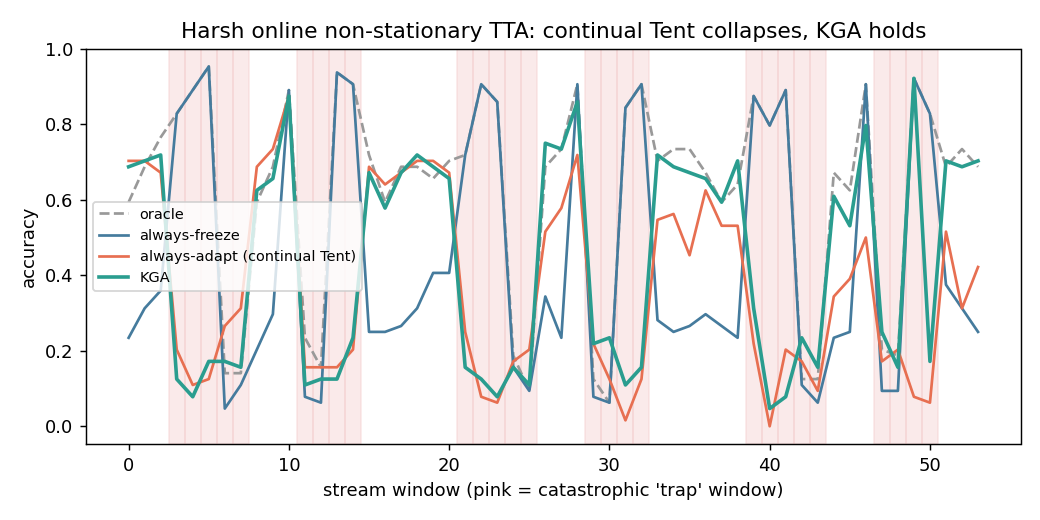

In [3]:
fig('fig_cifar10c_collapse.png'); fig('fig_cifar10c_crossover.png'); fig('fig_cifar_tent_online.png')

**Honest scope.** Per-corruption CIFAR-10-C is helpful-dominated, so always-adapt is strong and KGA
matches it at equal safety; KGA's distinctive value is **safety + cross-regime robustness** (it never
collapses). Full 1000-class ImageNet-C is pending (host unreachable). Reproduce: `bash scripts/rebuild_kbound.sh`.
